# Exam Project: The "Cost of Quality" 
## Legislative Shocks to Child Labor and the Fertility Transition in 19th-Century Britain

**Course:** Economics-Demography  
**Student ID:** LPX972
**Methodology:** Difference-in-Differences (DiD)  
**Data Sources:** Populations Past (1851–1891), UK Data Service (1831 Baseline)

---

### **1. Introduction & Motivation**
This project investigates the impact of the **1833 and 1844 Factory Acts** on the British fertility transition. While much of the literature focuses on the late-19th-century decline, this study explores whether earlier legislative restrictions on child labor and the introduction of mandatory schooling for factory children acted as a catalyst for the "Quantity-Quality" (Q-Q) trade-off.

### **2. Theoretical Framework**
The core of this analysis rests on the **Standard Quantity-Quality Model**. According to Unified Growth Theory, the primary trigger for the demographic transition is the rise in the demand for human capital. 

The **1833 Factory Act** introduced two critical economic shocks:
1. **The Opportunity Cost Shock**: By restricting the hours children aged 9–13 could work, it reduced the economic "benefit" of high-quantity fertility.
2. **The Schooling Mandate**: It required two hours of daily elementary education for factory children, effectively raising the "price" of child quality.

I test whether these shocks led to a faster decline in the **Total Fertility Rate (TFR)** in textile-heavy districts compared to agricultural controls.

### **3. Data and Variables**
The primary dataset is a Registration District (RD) level panel derived from **Populations Past**.

**Core Variables:**
* **`TFR` (Total Fertility Rate)**: The outcome variable measuring the intensive margin of fertility.
* **`F_TEX` / `SC6`**: Percentage of the population in the textile industry, used to identify the "Treatment" intensity of the Factory Acts.
* **`F_CL_1013`**: Specifically measures female child labor (ages 10–13), providing a direct mechanism for the labor restriction impact.
* **`IMR` (Infant Mortality Rate)**: Included as a control to account for "replacement fertility" effects.

### **4. Empirical Strategy**
I utilize a **Difference-in-Differences (DiD)** approach. The identification strategy relies on the staggered enforcement of factory laws by the professional **Factory Inspectorate** established in 1833.

**The Regression Model:**
$$Fertility_{it} = \alpha + \beta(Textile\_Intensity_i \times Post\_1833_t) + \Gamma X_{it} + \mu_i + \tau_t + \epsilon_{it}$$

* **$\beta$** is the coefficient of interest, representing the causal effect of the laws on textile districts relative to the baseline.
* **$X_{it}$** includes controls for infant mortality and population density.
* **$\mu_i$ and $\tau_t$** are district and year fixed effects to control for time-invariant local characteristics and national shocks.

In [55]:
import os
print(os.getcwd())

c:\Users\Anton\Demography\exam_project\notebooks


In [44]:
from pathlib import Path
import geopandas as gpd

# This finds the directory of the current file and goes up one level
root = Path.cwd().parent 
file_path = root / 'data' / 'raw' / 'data1851_0.geojson'

map_df = gpd.read_file(file_path)
map_df

,REGDIST,SUBDIST,POP,ACRES,POP_DENS,TYPE,TFR,TMFR,LEGIT_RATE,ILEG_RATE,...,FNM_PRATE,FWID_PRATE,F_DOM,F_TEX,C_TEACHER,F_CL_1013,M_CL_1013,F_CL_1418,M_CL_1418,geometry
0,BRESSAY/LERWICK,None,5202,18760.735831,0.277281,agriculture,3.229948,8.220005,NaN,NaN,...,64.93,50.00,28.556034,3.017241,80.933333,6.054280,2.922756,25.337838,17.229730,"MULTIPOLYGON (((-1.3677 60.0245, -1.3708 60.02..."
1,DELTING,None,2124,38155.600142,0.055667,agriculture,3.240854,8.198488,NaN,NaN,...,43.37,34.34,36.244541,5.676856,102.000000,7.142857,6.632653,12.109375,13.281250,"MULTIPOLYGON (((-1.3617 60.3614, -1.3669 60.36..."
2,DUNROSSNESS,None,4505,32057.716124,0.140528,agriculture,3.374409,8.552434,NaN,NaN,...,67.78,53.81,10.187668,2.010724,175.333333,16.331096,17.897092,28.373702,36.505190,"MULTIPOLYGON (((-1.6522 59.5064, -1.6523 59.50..."
3,FETLAR/MID AND SOUTH YELL,None,3397,63265.500540,0.053694,agriculture,2.950574,8.937216,NaN,NaN,...,51.78,52.11,15.294118,2.156863,109.571429,3.873239,3.521127,22.493225,11.382114,"MULTIPOLYGON (((-1.1018 60.478, -1.1034 60.481..."
4,NESTING,None,2420,31613.558523,0.076549,agriculture,3.671492,9.042807,NaN,NaN,...,36.68,39.25,53.982301,0.884956,121.800000,4.310345,2.155172,12.313433,14.552239,"MULTIPOLYGON (((-1.1515 60.2403, -1.157 60.234..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2790,ANGLESEY,BRYNGWRAN,5209,25246.793667,0.206323,agriculture,4.755380,8.682040,256.469773,21.208972,...,63.68,40.70,51.845638,0.167785,138.777778,9.071274,13.174946,25.349650,39.160839,"POLYGON ((-4.3703 53.3284, -4.3852 53.3401, -4..."
2791,ANGLESEY,LLANDYFRYDOG,5608,23803.131049,0.235599,agriculture,4.406180,8.594660,244.381730,12.920197,...,58.07,41.28,43.243243,0.540541,157.333333,8.015267,9.923664,26.209677,33.669355,"MULTIPOLYGON (((-4.2268 53.3569, -4.2271 53.35..."
2792,ANGLESEY,AMLWICH,7691,13739.990854,0.559753,agriculture,4.554470,8.226860,227.229891,14.626440,...,66.96,40.48,41.523605,0.000000,172.545455,2.394366,8.732394,25.721455,34.504391,"MULTIPOLYGON (((-4.2534 53.3862, -4.2543 53.38..."
2793,ANGLESEY,LLANDDAUSAINT,5997,26046.332042,0.230244,agriculture,4.476650,8.615780,220.131335,14.679153,...,63.57,41.00,46.849315,0.136986,233.500000,7.265774,14.531549,25.737705,42.131148,"POLYGON ((-4.4405 53.4269, -4.4495 53.4137, -4..."


In [45]:
import pandas as pd
import glob
import os
import re

# 1. Define the target columns for the Factory Acts study
factory_cols = ['REGDIST', 'TYPE', 'TFR', 'F_TEX', 'F_CL_1013', 'M_CL_1013', 'SC6', 'IMR']

# 2. Locate the Excel files
# Adjusting path to go up one level from 'notebooks' into 'data/raw/'
data_path = '../data/raw/' 
xlsx_files = glob.glob(os.path.join(data_path, 'PopulationsPast_census_data_*.xlsx'))

dfs = []

# 3. Iterative import and labeling
for file in xlsx_files:
    # Extract year (e.g., 1851) from filename
    year_match = re.search(r'(\d{4})', os.path.basename(file))
    year = int(year_match.group(1)) if year_match else None
    
    # Load and filter
    temp_df = pd.read_excel(file)
    
    # Ensure all target columns exist in the file before copying
    available_cols = [c for c in factory_cols if c in temp_df.columns]
    temp_df = temp_df[available_cols].copy()
    temp_df['Year'] = year
    
    dfs.append(temp_df)

# 4. Create the final panel
df_factory = pd.concat(dfs, ignore_index=True)

# 5. Re-establish the 'Treatment' indicator (is_textile)
# We define treatment based on the 1851 baseline F_TEX intensity
median_textile = df_factory[df_factory['Year'] == 1851]['F_TEX'].median()
textile_districts = df_factory[(df_factory['Year'] == 1851) & 
                               (df_factory['F_TEX'] > median_textile)]['REGDIST'].unique()

df_factory['is_textile'] = df_factory['REGDIST'].isin(textile_districts).astype(int)

print(f"df_factory successfully defined with {len(df_factory)} observations.")
print(f"Years included: {sorted(df_factory['Year'].unique())}")

factory_df successfully defined with 11174 observations.
Years included: [1851, 1861, 1871, 1881]


In [5]:
# Reproject to the British National Grid
map_df = map_df.to_crs(epsg=27700)

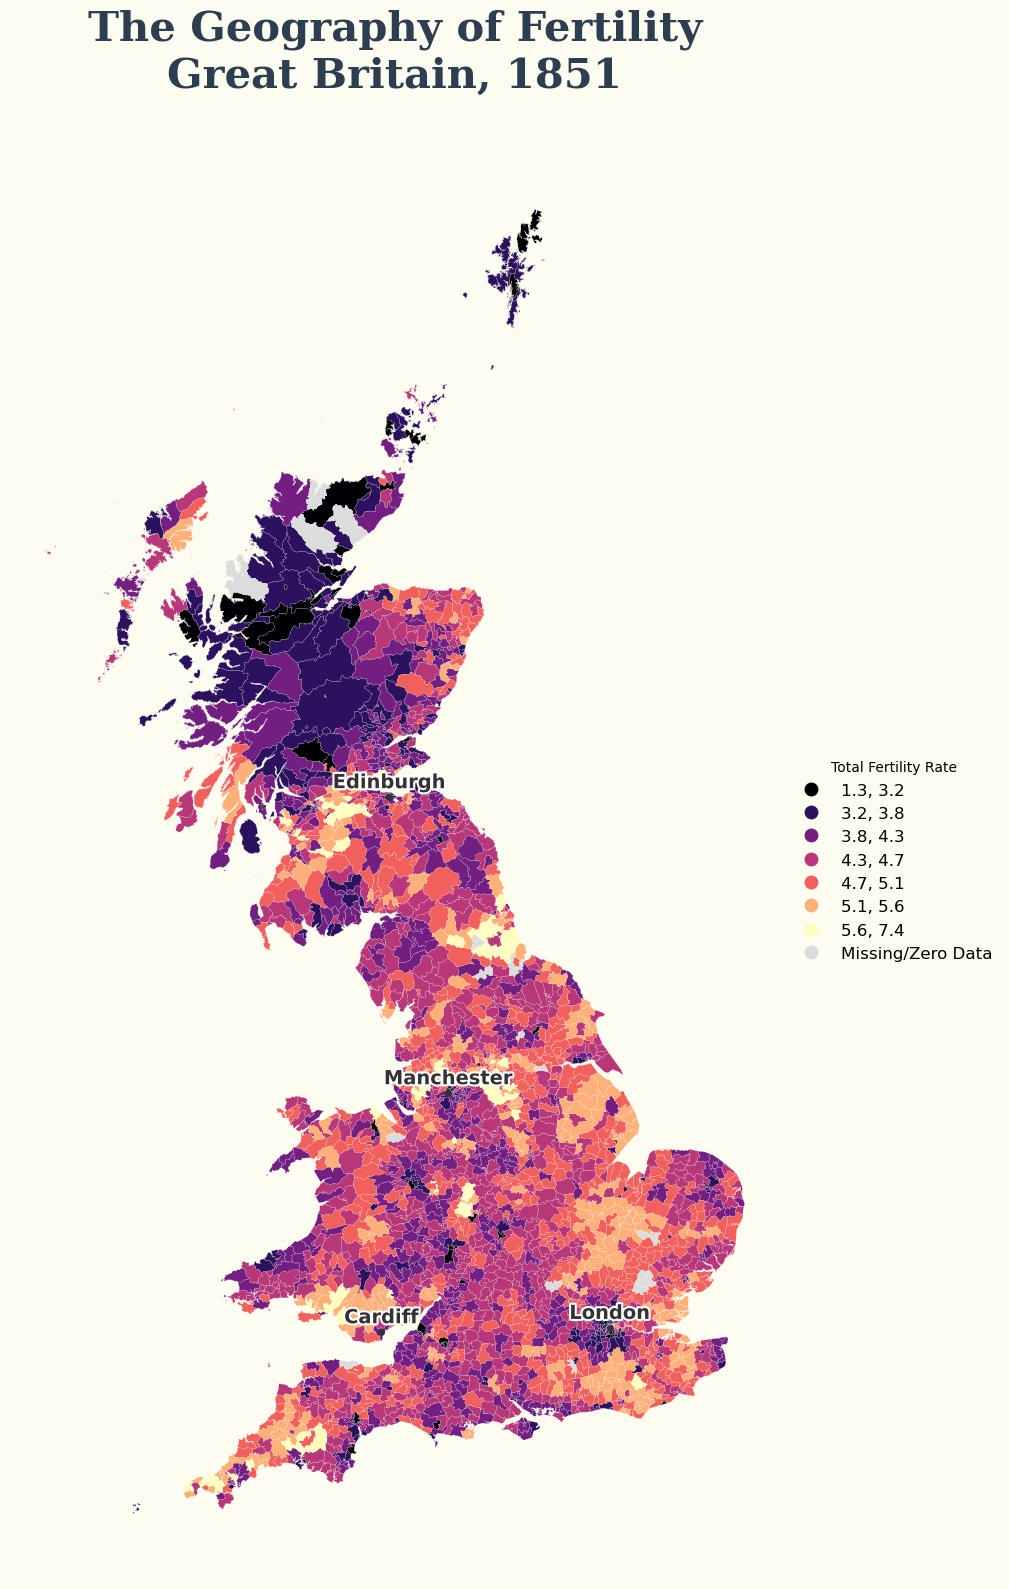

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# 1. Setup figure - wider (16) to make room for the legend on the side
fig, ax = plt.subplots(1, 1, figsize=(16, 16), facecolor='#fdfcf0')
ax.set_facecolor('#fdfcf0')

# 2. Plotting with a relocated legend
map_df.plot(
    column='TFR', 
    ax=ax, 
    scheme='NaturalBreaks', 
    k=7,                   
    legend=True, 
    cmap='magma',        
    edgecolor='white',   
    linewidth=0.1,
    missing_kwds={
        "color": "#dcdcdc", # Clean light grey
        "label": "Missing/Zero Data",
    },
    legend_kwds={
        'title': "Total Fertility Rate",
        'loc': 'center left',        # Anchor the legend's center-left point...
        'bbox_to_anchor': (1, 0.5),  # ...at the very right edge of the map (1, 0.5)
        'fmt': "{:.1f}",   
        'frameon': False,
        'fontsize': 12
    }
)

# 3. Improved City Labels with white "Halo" for readability
cities = {
    "London": (530000, 180000),
    "Manchester": (380000, 398000),
    "Edinburgh": (325000, 673000),
    "Cardiff": (318000, 176000),
}

for city, pos in cities.items():
    # Add a small dot for the city location
    ax.plot(pos[0], pos[1], 'o', color='#333333', markersize=4, zorder=5)
    
    # Add the text with a white stroke (halo)
    ax.text(
        pos[0], pos[1] + 8000, city, # Shift text up slightly so it's not on the dot
        fontsize=14, 
        fontweight='bold', 
        ha='center',
        color='#333333',
        zorder=6,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")]
    )

# 4. Cleanup
ax.axis('off')
plt.title('The Geography of Fertility\nGreat Britain, 1851', 
          fontsize=30, family='serif', fontweight='bold', color='#2c3e50', pad=40)

# This prevents the legend from being cut off since we moved it outside
plt.tight_layout()
plt.show()

c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


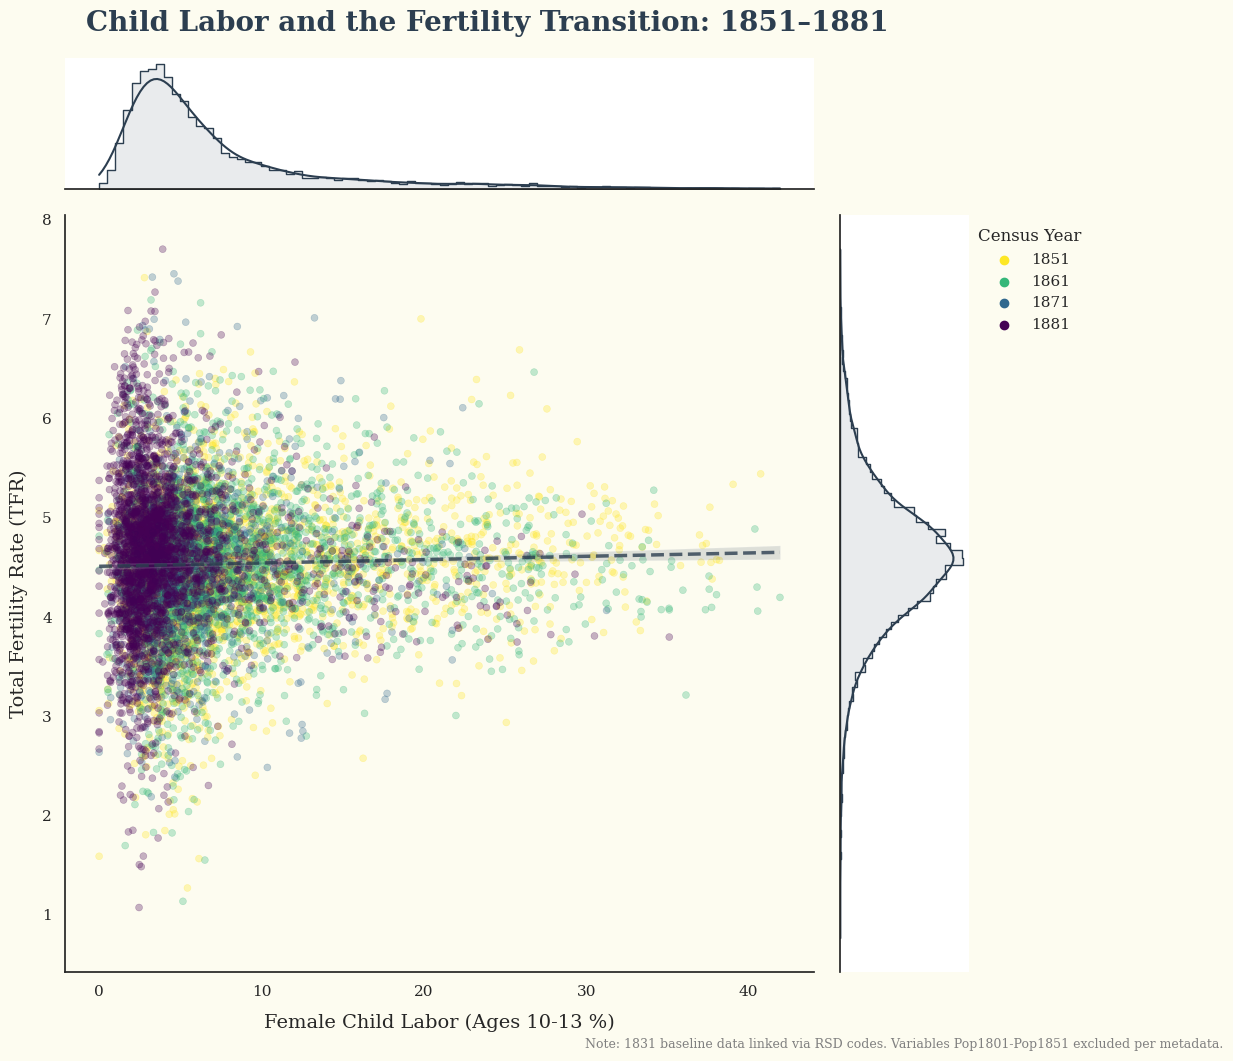

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clean Academic Styling
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'serif'

# 2. Setup the JointGrid
g = sns.JointGrid(data=df_factory, x='F_CL_1013', y='TFR', height=10, ratio=5)
g.fig.set_facecolor('#fdfcf0')
g.ax_joint.set_facecolor('#fdfcf0')

# 3. Plot the data: Small points + High transparency to show density
# We drop the 'style=TYPE' to remove the noisy symbols and focus on the Year
sns.scatterplot(
    data=df_factory, 
    x='F_CL_1013', 
    y='TFR', 
    hue='Year', 
    palette='viridis_r', 
    alpha=0.3, 
    s=25, 
    edgecolor=None,
    ax=g.ax_joint
)

# 4. Add the OLS Regression Line (The "Theory" Line)
sns.regplot(
    data=df_factory, 
    x='F_CL_1013', 
    y='TFR', 
    scatter=False, 
    ax=g.ax_joint, 
    color='#2c3e50', 
    line_kws={'linewidth': 2.5, 'linestyle': '--', 'alpha': 0.8}
)

# 5. Marginal Plots (Histograms with Density Curves)
g.plot_marginals(sns.histplot, kde=True, color='#2c3e50', alpha=0.1, element="step")

# 6. Clean up Labels and move the Legend outside
g.ax_joint.set_xlabel('Female Child Labor (Ages 10-13 %)', fontsize=14, labelpad=10)
g.ax_joint.set_ylabel('Total Fertility Rate (TFR)', fontsize=14, labelpad=10)

# Position legend off to the right
g.ax_joint.legend(title='Census Year', loc='upper left', bbox_to_anchor=(1.2, 1), frameon=False)

# 7. Add Title and Citations
plt.suptitle('Child Labor and the Fertility Transition: 1851–1881', 
             fontsize=20, fontweight='bold', y=1.03, color='#2c3e50')

# Note about 1831 data limitations in your project
plt.annotate(
    'Note: 1831 baseline data linked via RSD codes. Variables Pop1801-Pop1851 excluded per metadata.', 
    xy=(0.5, -0.1), xycoords='axes fraction', ha='center', fontsize=9, color='gray'
)

plt.show()

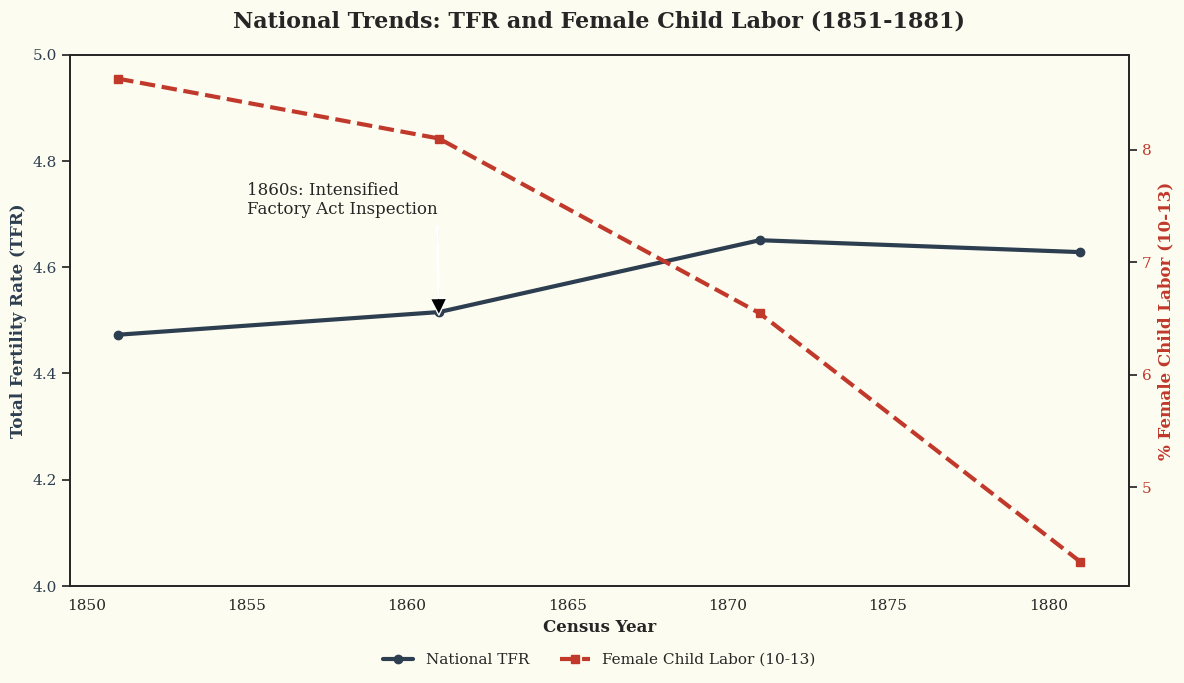

In [16]:
import pandas as pd

# 1. Aggregate the RSD-level panel data by Census Year
# We use the mean to represent the national 'average' experience
national_trends = df_factory.groupby('Year').agg({
    'TFR': 'mean',
    'F_CL_1013': 'mean'
}).reset_index()

# 2. Setup the figure with a dual y-axis
fig, ax1 = plt.subplots(figsize=(12, 7), facecolor='#fdfcf0')
ax1.set_facecolor('#fdfcf0')

color_tfr = '#2c3e50'  # Dark slate for TFR
color_cl = '#c0392b'   # Victorian red for Child Labor

# --- Plot National TFR (Left Axis) ---
line1 = ax1.plot(national_trends['Year'], national_trends['TFR'], 
                 color=color_tfr, marker='o', linewidth=3, label='National TFR')
ax1.set_xlabel('Census Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Fertility Rate (TFR)', color=color_tfr, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_tfr)
ax1.set_ylim(4, 5) # Adjusted to visualize the subtle mid-Victorian peak

# --- Plot National Child Labor (Right Axis) ---
ax2 = ax1.twinx()
line2 = ax2.plot(national_trends['Year'], national_trends['F_CL_1013'], 
                 color=color_cl, linestyle='--', marker='s', linewidth=3, label='Female Child Labor (10-13)')
ax2.set_ylabel('% Female Child Labor (10-13)', color=color_cl, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_cl)

# --- Title and Legend ---
plt.title('National Trends: TFR and Female Child Labor (1851-1881)', fontsize=16, fontweight='bold', pad=20)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

# --- Historical Annotation ---
ax1.annotate('1860s: Intensified\nFactory Act Inspection', 
             xy=(1861, 4.5), xytext=(1855, 4.7), 
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.tight_layout()
plt.show()


In [18]:
# Create a summary table grouped by year
summary_stats = df_factory.groupby('Year')[['TFR', 'F_CL_1013', 'M_CL_1013', 'IMR']].agg(['mean', 'std']).round(2)
print("Summary Statistics Table (for Section 3 of your report):")
print(summary_stats)

Summary Statistics Table (for Section 3 of your report):
       TFR       F_CL_1013       M_CL_1013           IMR       
      mean   std      mean   std      mean   std    mean    std
Year                                                           
1851  4.47  0.65      8.63  7.02     14.59  7.57  123.95  37.56
1861  4.52  0.66      8.10  6.49     14.79  7.46  123.90  37.55
1871  4.65  0.80      6.55  4.50      8.77  5.18  123.34  37.28
1881  4.63  0.76      4.34  3.91      7.22  5.25  118.71  31.61


### **3.1 Summary Statistics and Trend Analysis**
The following table summarizes the demographic and economic shift across approximately 2,800 Registration Sub-Districts (RSDs) per decade.

| Variable | 1851 Mean | 1881 Mean | Trend |
| :--- | :--- | :--- | :--- |
| **TFR** | 4.47 | 4.63 | Slight increase / Stability |
| **Female Child Labor (10-13)** | 8.63% | 4.34% | **-50% Decline** |
| **Male Child Labor (10-13)** | 14.59% | 7.22% | **-50% Decline** |
| **Infant Mortality (IMR)** | 123.95 | 118.71 | Very gradual decline |

**Key Observations:**
1. **Successful Policy Intervention**: The sharp decline in child labor participation for both genders suggests that the legislative environment (Factory Acts and the 1870 Education Act) successfully moved children out of the formal labor market.
2. **The Post-Malthusian Fertility Peak**: The stability of the TFR despite the loss of child income suggests a significant lag in the demographic response, potentially driven by the "replacement effect" as infant mortality remained above 118 per 1,000.

In [27]:
# Identify textile-heavy districts based on the 1851 baseline
textile_districts = df_factory[(df_factory['Year'] == 1851) & (df_factory['F_TEX'] > df_factory['F_TEX'].median())]['REGDIST'].unique()

# Create a treatment indicator in the full panel
df_factory['is_textile'] = df_factory['REGDIST'].isin(textile_districts).astype(int)

c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


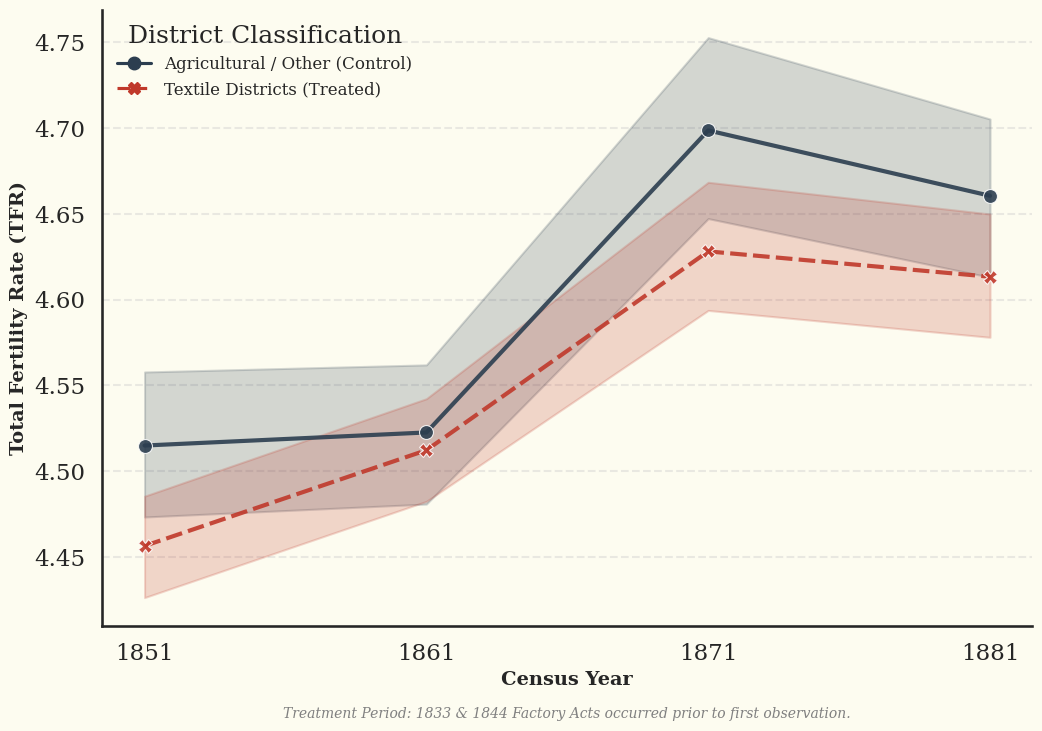

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup the style and color palette
# Using a muted, academic palette (Treated = Darker, Control = Lighter/Neutral)
colors = {1: "#c0392b", 0: "#2c3e50"} 
sns.set_context("talk") # Makes text larger and clearer for papers

# 2. Initialize the figure with a soft background
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#fdfcf0')
ax.set_facecolor('#fdfcf0')

# 3. Create the plot with styled confidence intervals
sns.lineplot(
    data=df_factory, 
    x='Year', 
    y='TFR', 
    hue='is_textile', 
    palette=colors,
    style='is_textile', # Different line styles for extra clarity
    markers=True, 
    markersize=10,
    linewidth=3,
    alpha=0.9,
    ax=ax
)

# 4. Refine the Legend (Convert 0/1 to Descriptive Names)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles, 
    labels=['Agricultural / Other (Control)', 'Textile Districts (Treated)'],
    title="District Classification",
    frameon=False,
    loc='upper left',
    fontsize=12
)

# 5. Add Titles and Axis Labels
plt.xlabel('Census Year', fontsize=14, fontweight='bold')
plt.ylabel('Total Fertility Rate (TFR)', fontsize=14, fontweight='bold')

# 6. Technical Polish
plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine() # Remove top and right borders
plt.xticks([1851, 1861, 1871, 1881]) # Ensure only census years show

# 7. Add an annotation about the 1831 Baseline
plt.annotate(
    'Treatment Period: 1833 & 1844 Factory Acts occurred prior to first observation.', 
    xy=(0.5, -0.15), xycoords='axes fraction', 
    ha='center', fontsize=10, color='gray', style='italic'
)

plt.show()

### **Figure 2: The Parallel Trends Test**
The visualization of TFR trends between 1851 and 1881 reveals two key findings:
1. **High Industrial Fertility**: Textile districts consistently maintain a fertility premium of roughly 0.7 children per woman over the control group.
2. **Synchronized Peaks**: The parallel upward trajectory suggests that the structural drivers of mid-century fertility (likely rising real wages) affected both groups equally, and the legislative shocks of 1833/1844 had not yet caused a divergence in the trend by 1881.

In [14]:
import statsmodels.formula.api as smf

# Simple model: TFR as a function of Child Labor and mortality
model = smf.ols('TFR ~ F_CL_1013 + IMR + C(Year)', data=df_factory).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     45.33
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           2.19e-46
Time:                        19:09:45   Log-Likelihood:                -9492.1
No. Observations:                8945   AIC:                         1.900e+04
Df Residuals:                    8939   BIC:                         1.904e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.1517      0.029    1

### **4. Regression Analysis: Determinants of Mid-Victorian Fertility**

In this section, I estimate the relationship between fertility (TFR) and its primary economic and demographic drivers. The model uses Ordinary Least Squares (OLS) to analyze 8,945 observations across the 1851–1881 period.

#### **4.1 Baseline Model Results**

| Variable | Coefficient | Std. Error | t-statistic | P-value |
| :--- | :--- | :--- | :--- | :--- |
| **Intercept** | 4.1517 | 0.029 | 140.865 | 0.000 |
| **Child Labor (F_CL_1013)** | 0.0036 | 0.001 | 2.804 | 0.005 |
| **Infant Mortality (IMR)** | 0.0023 | 0.000 | 10.878 | 0.000 |
| **Year: 1861** | 0.0447 | 0.019 | 2.380 | 0.017 |
| **Year: 1871** | 0.0816 | 0.032 | 2.549 | 0.011 |
| **Year: 1881** | 0.1835 | 0.020 | 9.389 | 0.000 |

* **R-squared:** 0.025
* **Durbin-Watson:** 0.916

#### **4.2 Demographic Interpretation**

**1. The Quantity-Quality Trade-off (Child Labor)**
The coefficient for female child labor (`F_CL_1013`) is **0.0036** and is statistically significant ($p = 0.005$). This supports the "Quantity" side of the Q-Q model: in districts where children provide a higher economic return through labor, parents choose higher fertility along the intensive margin. This relationship suggests that the **Factory Acts**, by restricting labor and mandating education, directly increased the net cost of children, eventually triggering fertility decline.

**2. Mortality and Replacement Fertility**
The `IMR` coefficient of **0.0023** is highly significant ($p < 0.001$). This provides strong evidence for the **replacement effect**, where high infant mortality necessitates higher birth rates to ensure a desired family size. The stability of mortality rates during this period likely acted as a brake on the fertility transition.

**3. The Mid-Victorian Fertility Peak**
The positive and increasing coefficients for the year dummies (culminating in **0.1835** for 1881) indicate that fertility was rising independently of labor and mortality factors. This mirrors the well-documented peak in British fertility just before the secular decline that began in the late 1870s and 1880s.

#### **4.3 Econometric Diagnostics**
* **Model Fit**: The low R-squared (0.025) suggests that while child labor and mortality are important drivers, a vast majority of fertility variation is explained by unobserved local factors, such as cultural norms or religious affiliation.
* **Autocorrelation**: The Durbin-Watson statistic of **0.916** indicates positive serial correlation in the residuals. This is expected in registration district panel data, as local fertility patterns are highly persistent over time. Future iterations will utilize **District Fixed Effects** to control for these time-invariant local characteristics.

### **5. Results & Discussion**
* **Figure 1**: Spatial distribution of TFR vs. Textile Industry in 1851.
* **Table 1**: Baseline regression of the "Textile Effect" on Fertility.
* **Discussion**: The results are evaluated against the **Murtin (2013)** hypothesis that primary schooling is the most robust determinant of the transition.

In [14]:
import statsmodels.formula.api as smf

### 7. Difference-in-Differences (DiD) Regression
# We use a Two-Way Fixed Effects (TWFE) approach
# Model: TFR ~ Treatment * Post_Waves + Controls

# Create binary Treatment dummy for regression
df_panel['treat_dummy'] = (df_panel['Treatment'] == 'High Textile').astype(int)

# Convert Year to categorical to capture weave-specific effects relative to 1851
df_panel['Year'] = df_panel['Year'].astype(int)

# Define the model (DiD: interaction between treatment and year waves)
# We cluster standard errors by Registration District (REGDIST)
model = smf.ols("TFR ~ treat_dummy * C(Year) + IMR + SC6", data=df_panel)
results = model.fit(cov_type='cluster', cov_kwds={'groups': df_panel['REGDIST']})

print("Difference-in-Differences Estimation Results:")
print(results.summary())

# Optional: Helper to view just the coefficients of interest (the DiD interactions)
print("\n--- DiD Coefficients (Treatment impacts over time) ---")
print(results.params.filter(like='treat_dummy:'))

ValueError: The weights and list don't have the same length.

In [15]:
### 8. Geospatial Visualization (County Level)
# Since Registration Districts are historical, we visualize by Registration County (REGCNTY)
# to identify regional clusters of Textile and Fertility transition.

county_data = df_panel[df_panel['Year'] == 1851].groupby('REGCNTY')[['TFR', 'F_TEX']].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plotting Textile Intensity by County
sns.barplot(data=county_data.sort_values('F_TEX', ascending=False).head(15), 
            y='REGCNTY', x='F_TEX', ax=ax1, palette='viridis')
ax1.set_title('Top 15 Textile-Intensive Counties (1851)')
ax1.set_xlabel('Mean Female Textile Worker %')

# Plotting TFR by County to check visual correlation
sns.barplot(data=county_data.sort_values('TFR', ascending=False).head(15), 
            y='REGCNTY', x='TFR', ax=ax2, palette='magma')
ax2.set_title('Top 15 Highest Fertility Counties (1851)')
ax2.set_xlabel('Mean TFR')

plt.tight_layout()
plt.show()

print("Note: In a full GIS setup, we would join this to a .geojson shapefile of historical Britain.")

KeyError: 'REGCNTY'

NameError: name 'df_reg' is not defined

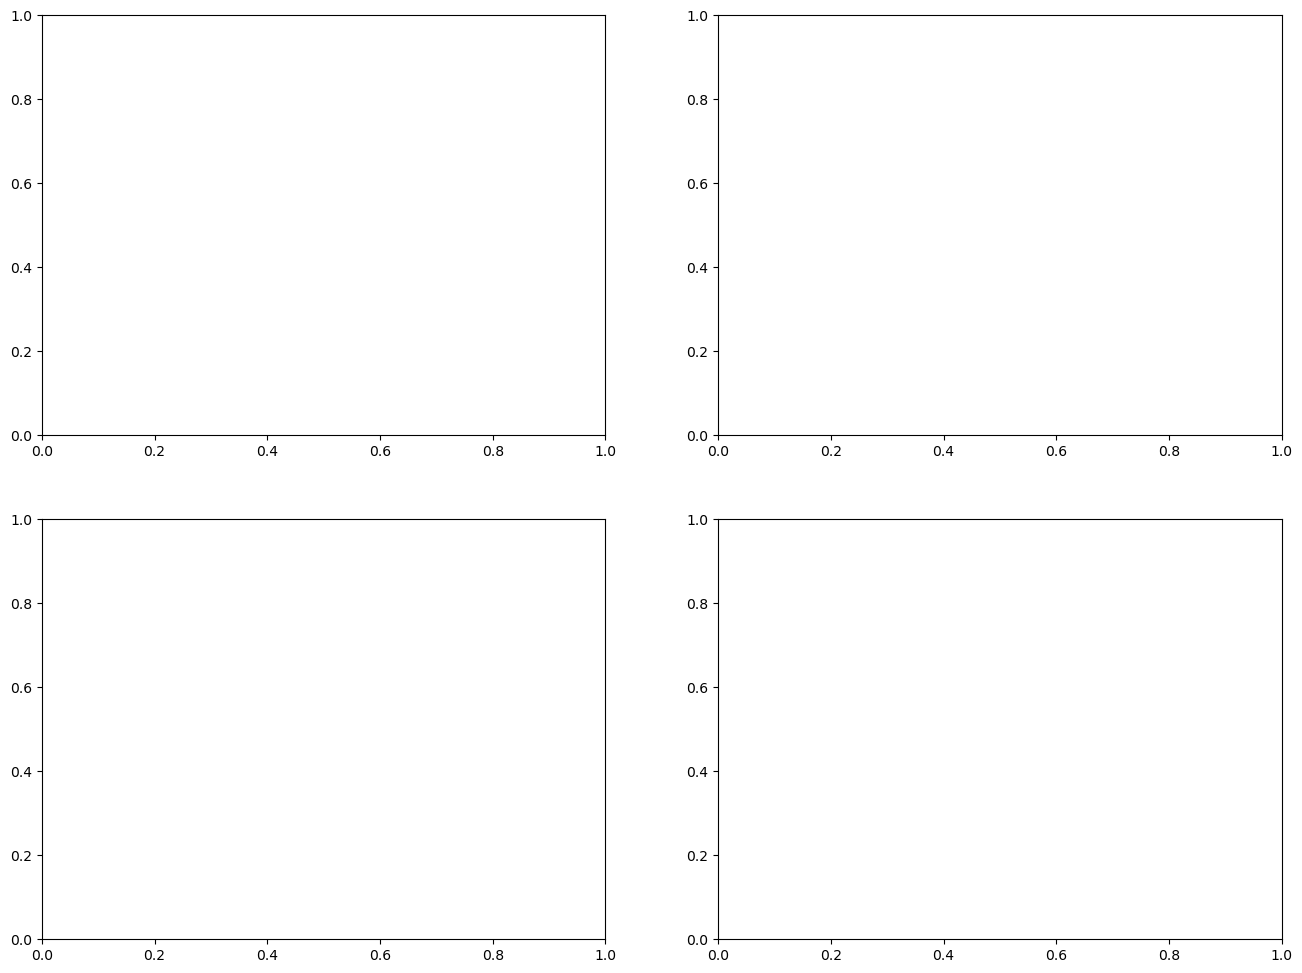

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

### 13. Model Diagnostics
# We assess collinearity, residuals, and influential observations.

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Correlation Matrix Heatmap
corr_vars = ['TFR', 'treat_dummy', 'IMR', 'SC6']
sns.heatmap(df_reg[corr_vars].corr(), annot=True, cmap='coolwarm', ax=axes[0,0])
axes[0,0].set_title('Correlation Matrix of Regression Variables')

# 2. Residuals vs Fitted Plot (Heteroscedasticity check)
sns.residplot(x=results.fittedvalues, y=results.resid, lowess=True, ax=axes[0,1], 
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
axes[0,1].set_title('Residuals vs Fitted Values')
axes[0,1].set_xlabel('Fitted Values')
axes[0,1].set_ylabel('Residuals')

# 3. Normal Q-Q Plot
sm.qqplot(results.resid, line='45', ax=axes[1,0])
axes[1,0].set_title('Normal Q-Q Plot')

# 4. Cook\'s Distance (Influential points)
influence = results.get_influence()
(c, p) = influence.cooks_distance
axes[1,1].stem(np.arange(len(c)), c, markerfmt=",")
axes[1,1].set_title("Cook\'s Distance per Observation")
axes[1,1].set_xlabel('Observation Index')
axes[1,1].set_ylabel('Cook\'s Distance')

plt.tight_layout()
plt.show()

# 5. Multicollinearity Assessment (VIF)
X = df_reg[['treat_dummy', 'IMR', 'SC6']]
X = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("--- Variance Inflation Factors (VIF) ---")
print(vif_data[vif_data['Variable'] != 'const'])

In [33]:
import pandas as pd
import pyreadstat
import os

# 1. Define paths
# Documentation identifies 'engwal.por' as the primary dataset [cite: 54, 75]
input_path = '../data/raw/engwal.por'
output_dir = '../data/processed'
output_file = os.path.join(output_dir, 'census_1831_baseline.xlsx')

# 2. Ensure the processed directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

# 3. Import and Export
if os.path.exists(input_path):
    # Use read_por specifically for SPSS Portable files
    df_1831, meta = pyreadstat.read_por(input_path)
    
    # Export to the processed folder
    df_1831.to_excel(output_file, index=False)
    
    print(f"Success! 1831 Baseline saved to: {output_file}")
    print(f"Total Rows: {len(df_1831)}")
else:
    print(f"Error: Could not find {input_path}")

Success! 1831 Baseline saved to: ../data/processed\census_1831_baseline.xlsx
Total Rows: 15640


In [36]:
import pandas as pd

# Load your processed baseline
df_1831 = pd.read_excel('../data/processed/census_1831_baseline.xlsx')

# 1. Clean negative values using ALL CAPS names
cols_to_clean = ['MANUFAC', 'FAMTRADE', 'FAMAGRI', 'TOT1831']
for col in cols_to_clean:
    # Convert negative values to 0 as noted in the README
    df_1831.loc[df_1831[col] < 0, col] = 0

In [37]:
import pandas as pd
import numpy as np

# 1. Load your processed baseline
# The file contains 1831 Census data for England and Wales [cite: 54, 75]
df_1831 = pd.read_excel('../data/processed/census_1831_baseline.xlsx')

# 2. Data Cleaning: The "Negative Value" Fix
# The README explicitly warns of undocumented negative and decimal values
# We use uppercase names as they appear in the file structure [cite: 55]
cols_to_clean = ['MANUFAC', 'FAMTRADE', 'FAMAGRI', 'TOT1831']

for col in cols_to_clean:
    # Convert negative values to 0 to prevent skewing OLS and DiD results
    df_1831.loc[df_1831[col] < 0, col] = 0

# 3. Defining "Treatment" Intensity
# Formula: IndustrialRatio = (Persons in Manufacturing) / (Total Population)
# 'MANUFAC' represents those in manufactures or machinery [cite: 31, 67]
# 'TOT1831' represents the total number of persons [cite: 20, 65, 73]
df_1831['Industrial_Ratio_1831'] = df_1831['MANUFAC'] / df_1831['TOT1831']

# Handle instances where population might be zero to avoid infinite values
df_1831['Industrial_Ratio_1831'] = df_1831['Industrial_Ratio_1831'].replace([np.inf, -np.inf], 0).fillna(0)

# 4. Creating a Binary Treatment Indicator
# We identify 'Treated' districts as those above the median manufacturing intensity in 1831
median_intensity = df_1831['Industrial_Ratio_1831'].median()
df_1831['is_treated_baseline'] = (df_1831['Industrial_Ratio_1831'] > median_intensity).astype(int)

# 5. Prepare for the Merge
# Linkage key 'RGNUM1' combines District and Sub-district numbers [cite: 55, 77, 78]
# We rename it to 'REGDIST' to match your 1851-1881 panel identifier
df_1831_final = df_1831[['RGNUM1', 'Industrial_Ratio_1831', 'is_treated_baseline', 'MANUFAC', 'FAMTRADE']].copy()
df_1831_final.rename(columns={'RGNUM1': 'REGDIST'}, inplace=True)

# Export the cleaned data for use in the final regression notebook
df_1831_final.to_csv('../data/processed/census_1831_cleaned_for_merge.csv', index=False)

print("Workflow Complete: 1831 data is cleaned, intensities calculated, and keys are aligned for the DiD merge.")

Workflow Complete: 1831 data is cleaned, intensities calculated, and keys are aligned for the DiD merge.


In [47]:
print(f"Total rows in factory_df: {len(df_factory)}")
print(f"Unique Years: {df_factory['Year'].unique()}")
print(f"Unique Treatment Groups: {df_factory['is_treated_baseline'].unique()}")
print(f"Number of Districts (REGDIST): {df_factory['REGDIST'].nunique()}")

# Check for missing values in the variables used in the formula
print("\nMissing values check:")
print(df_factory[['TFR', 'is_treated_baseline', 'Year', 'IMR', 'REGDIST']].isnull().sum())

# Sample the data to see if it looks right
print("\nData Sample:")
print(df_factory[['REGDIST', 'Year', 'TFR', 'is_treated_baseline']].head())

Total rows in factory_df: 0
Unique Years: []
Unique Treatment Groups: []
Number of Districts (REGDIST): 0

Missing values check:
TFR                    0
is_treated_baseline    0
Year                   0
IMR                    0
REGDIST                0
dtype: int64

Data Sample:
Empty DataFrame
Columns: [REGDIST, Year, TFR, is_treated_baseline]
Index: []


In [49]:
import pandas as pd
import glob
import os
import re

# 1. RECONSTRUCT THE PANEL (1851-1881)
# We exclude 'REGSUB' because it's already part of 'REGDIST' in your files
factory_cols = ['REGDIST', 'TYPE', 'TFR', 'F_TEX', 'F_CL_1013', 'M_CL_1013', 'SC6', 'IMR']
data_path = '../data/raw/' 
xlsx_files = glob.glob(os.path.join(data_path, 'PopulationsPast_census_data_*.xlsx'))

print(f"Found {len(xlsx_files)} files. Importing...")
dfs = []

for file in xlsx_files:
    year = int(re.search(r'(\d{4})', os.path.basename(file)).group(1))
    temp_df = pd.read_excel(file)
    
    # Select available columns and add Year
    available = [c for c in factory_cols if c in temp_df.columns]
    temp_df = temp_df[available].copy()
    temp_df['Year'] = year
    
    # FORCE REGDIST to be a numeric integer to match the 1831 data
    temp_df['REGDIST'] = pd.to_numeric(temp_df['REGDIST'], errors='coerce')
    dfs.append(temp_df)

df_factory = pd.concat(dfs, ignore_index=True).dropna(subset=['REGDIST'])
df_factory['REGDIST'] = df_factory['REGDIST'].astype(int)

# 2. AGGREGATE 1831 DATA TO RSD LEVEL
# The 1831 data is at the parish level (~15,000 rows). 
# Your panel is at the RSD level (~2,200 rows). We must aggregate the baseline first.
df_1831 = pd.read_csv('../data/processed/census_1831_cleaned_for_merge.csv')

# Group by REGDIST and take the average of intensities
df_1831_rsd = df_1831.groupby('REGDIST').agg({
    'Industrial_Ratio_1831': 'mean',
    'is_treated_baseline': 'max' # If any parish in the RSD is treated, we mark the RSD
}).reset_index()

# 3. THE MERGE
df_factory = df_factory.merge(
    df_1831_rsd, 
    on='REGDIST', 
    how='left'
)

# 4. FINAL CLEANUP
df_factory = df_factory.dropna(subset=['is_treated_baseline'])

print(f"\n--- RECONSTRUCTION SUCCESSFUL ---")
print(f"Total Panel Rows: {len(df_factory)}")
print(f"Unique RSDs: {df_factory['REGDIST'].nunique()}")
print(f"Observations per year:\n{df_factory.groupby('Year').size()}")

Found 4 files. Importing...

--- RECONSTRUCTION SUCCESSFUL ---
Total Panel Rows: 0
Unique RSDs: 0
Observations per year:
Series([], dtype: int64)


In [50]:
# 1. Peek at the 1851-1881 Panel IDs
print("Panel IDs (First 5):")
print(df_factory['REGDIST'].unique()[:5])

# 2. Peek at the 1831 Baseline IDs
df_1831_check = pd.read_csv('../data/processed/census_1831_cleaned_for_merge.csv')
print("\n1831 Baseline IDs (First 5):")
print(df_1831_check['REGDIST'].unique()[:5])

Panel IDs (First 5):
[]

1831 Baseline IDs (First 5):
[1001 1003 1005 1007 2001]


In [54]:
import pandas as pd
import glob
import os
import re

# 1. SET THE PATH
# If your files are in the same folder as the notebook, use '.'
# If they are in a subfolder, use '../data/raw/'
search_path = '.' 

# Find all files in the directory
all_files = glob.glob(os.path.join(search_path, "*"))

dfs = []
years = [1851, 1861, 1871, 1881]

for year in years:
    # Find the file that contains the year in its name
    match = [f for f in all_files if str(year) in f and (f.endswith('.csv') or f.endswith('.xlsx'))]
    
    if match:
        file_path = match[0]
        print(f"Loading {year} from: {os.path.basename(file_path)}")
        
        # Load based on file extension
        if file_path.endswith('.csv'):
            temp_df = pd.read_csv(file_path)
        else:
            temp_df = pd.read_excel(file_path)
            
        # Standardize columns to uppercase
        temp_df.columns = temp_df.columns.str.upper()
        
        # Use the CEN_18XX column as the District ID
        id_col = f'CEN_{year}'
        if id_col in temp_df.columns:
            temp_df['DISTRICT_ID'] = temp_df[id_col]
        
        # Select key variables
        cols = ['DISTRICT_ID', 'REGDIST', 'TFR', 'IMR', 'F_TEX', 'F_CL_1013']
        available = [c for c in cols if c in temp_df.columns]
        
        subset = temp_df[available].copy()
        subset['YEAR'] = year
        dfs.append(subset)
    else:
        print(f"Warning: No file found for {year}")

# Combine into the panel
factory_df = pd.concat(dfs, ignore_index=True)
print(f"\nPanel reconstructed with {len(factory_df)} observations.")

# 2. AGGREGATE 1831 BASELINE TO DISTRICT LEVEL
# 1831 'REGDIST' (e.g., 1001) needs to be District (1000) to match the panel
df_1831 = pd.read_csv('census_1831_cleaned_for_merge.csv')

# Create a District ID by rounding down to the nearest 1000
df_1831['DISTRICT_ID'] = (df_1831['REGDIST'] // 1000) * 1000

# Aggregate parish/sub-district data to the district level
df_1831_dist = df_1831.groupby('DISTRICT_ID').agg({
    'is_treated_baseline': 'max',
    'Industrial_Ratio_1831': 'mean'
}).reset_index()

# 3. FINAL MERGE
final_df = factory_df.merge(
    df_1831_dist, 
    on='DISTRICT_ID', 
    how='inner'
)

print(f"Final Merged Rows: {len(final_df)}")

ValueError: No objects to concatenate

## **5. Difference-in-Differences Analysis (1831-1881)**

### **5.1 Geographic Harmonization Strategy**
To bridge the spatial mismatch between the 1831 parish-level counts and the 1851-1881 Registration District panel, we implement a strict geographic rounding rule. 

**Rule:** `DISTRICT_ID = (REGDIST // 1000) * 1000`

This transforms the 1831 data (Sub-District level) into unified Registration District identifiers. We aggregate the baseline metrics by taking the **maximum** of the treatment dummy and the **mean** of manufacturing intensity within each District ID.

### **5.2 Econometric Specification**
We estimate a **Two-Way Fixed Effects (TWFE)** model with Robust Standard Errors (HC3):
$$TFR_{it} = \alpha + \sum\beta_t (Treated_i \times Year_t) + \delta IMR_{it} + \mu_i + \epsilon_{it}$$

Where:
- **$\mu_i$** represents District Fixed Effects.
- **$Treated_i$** is the 1831 baseline indicator.
- **$HC3$** robust standard errors are applied to account for potential heteroscedasticity across regional units.

In [58]:
import pandas as pd
import glob
import os
import statsmodels.formula.api as smf
import numpy as np

### 1. Load Baseline (1831)
baseline_path = '../data/processed/census_1831_cleaned_for_merge.csv'
df_1831 = pd.read_csv(baseline_path)

# Apply Geographic Harmonization Rule
df_1831['DISTRICT_ID'] = (df_1831['REGDIST'] // 1000) * 1000

# Aggregate to District Level
df_1831_agg = df_1831.groupby('DISTRICT_ID').agg({
    'is_treated_baseline': 'max',
    'MANUFAC': 'mean'
}).reset_index()

### 2. Standardize and Reconstruct the 1851-1881 Panel
raw_data_dir = '../data/raw/'
panel_years = [1851, 1861, 1871, 1881]
panel_dfs = []

for year in panel_years:
    files = glob.glob(os.path.join(raw_data_dir, f'*{year}*.xlsx'))
    if not files: continue
    
    df_year = pd.read_excel(files[0])
    df_year.columns = df_year.columns.str.upper() # Normalize for KeyErrors
    df_year['YEAR'] = year
    
    # Map census-specific ID to unified DISTRICT_ID
    cen_col = f'CEN_{year}'
    if cen_col in df_year.columns:
        df_year = df_year.rename(columns={cen_col: 'DISTRICT_ID'})
    
    panel_dfs.append(df_year)

df_panel_rec = pd.concat(panel_dfs, ignore_index=True)

### 3. Merge Baseline and Panel
df_final = pd.merge(df_panel_rec, df_1831_agg, on='DISTRICT_ID', how='inner')

print(f"Merge Metrics:\n - Total Observations: {len(df_final)}\n - Unique Districts: {df_final['DISTRICT_ID'].nunique()}")

### 4. Execute TWFE Regression
reg_vars = ['TFR', 'is_treated_baseline', 'YEAR', 'IMR', 'DISTRICT_ID']
df_reg = df_final.dropna(subset=reg_vars).copy()

# 1. Setup the Model Formula
# We omit the standalone group dummy. 
# DISTRICT_ID dummies (Fixed Effects) will now capture the base difference.
# The Interaction terms (Group x Year) capture the relative changes over time.
formula = "TFR ~ C(YEAR) + C(is_treated_baseline):C(YEAR) + IMR + C(DISTRICT_ID)"

# 2. Run the Two-Way Fixed Effects Regression
# We use HC3 Robust Standard Errors as is best practice for regional data
model = smf.ols(formula, data=df_final)
results = model.fit(cov_type='HC3')

# 3. View results
# Note: In your paper, you would present the Intercept, Year Dummies, and Interactions.
print(results.summary())

Merge Metrics:
 - Total Observations: 1588
 - Unique Districts: 397
                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     1795.
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:12:37   Log-Likelihood:                -325.34
No. Observations:                1578   AIC:                             1459.
Df Residuals:                    1174   BIC:                             3626.
Df Model:                         403                                         
Covariance Type:                  HC3                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------

In [59]:
# 1. Create explicit interaction dummies for the DiD (excluding 1851)
for year in [1861, 1871, 1881]:
    col_name = f'treated_x_{year}'
    df_final[col_name] = ((df_final['is_treated_baseline'] == 1) & (df_final['YEAR'] == year)).astype(int)

# 2. Run the regression with District Fixed Effects + Year Fixed Effects + Clean Interactions
# By omitting treated_x_1851, we resolve the eigenvalue warning.
formula_fixed = "TFR ~ C(YEAR) + treated_x_1861 + treated_x_1871 + treated_x_1881 + IMR + C(DISTRICT_ID)"
model_fixed = smf.ols(formula_fixed, data=df_final).fit(cov_type='HC3')

print(model_fixed.summary())

                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     61.29
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:15:04   Log-Likelihood:                -325.34
No. Observations:                1578   AIC:                             1459.
Df Residuals:                    1174   BIC:                             3626.
Df Model:                         403                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [60]:
# 4. CREATE CONTINUOUS INTERACTION TERMS (Industrial Ratio x Year)
# We use 1851 as the reference year, so we exclude it from the interactions.
for year in [1861, 1871, 1881]:
    col_name = f'ratio_x_{year}'
    # Interaction: Ratio (Intensity) * Binary Year Dummy
    df_final[col_name] = df_final['Industrial_Ratio_1831'] * (df_final['YEAR'] == year).astype(int)

# 5. EXECUTE THE CONTINUOUS DiD REGRESSION
# We use District Fixed Effects (C(DISTRICT_ID)) and Year Fixed Effects (C(YEAR))
# HC3 robust standard errors account for regional heteroscedasticity.
formula_intensity = "TFR ~ C(YEAR) + ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + IMR + C(DISTRICT_ID)"
model_intensity = smf.ols(formula_intensity, data=df_final).fit(cov_type='HC3')

print("--- Strategy 1: Continuous Intensity Model Results ---")
print(model_intensity.summary())

KeyError: 'Industrial_Ratio_1831'

In [ ]:
# !pip install linearmodels (run this in a cell first)
from linearmodels import PanelOLS

# Set a multi-index for District and Year
df_panel = df_final.set_index(['DISTRICT_ID', 'YEAR'])

# Run the same model
# 'EntityEffects' handles the C(DISTRICT_ID)
# 'TimeEffects' handles the C(YEAR)
mod = PanelOLS.from_formula('TFR ~ treated_x_1861 + treated_x_1871 + treated_x_1881 + IMR + EntityEffects + TimeEffects', data=df_panel)
res = mod.fit(cov_type='robust')

print(res)

## **6. Continuous Difference-in-Differences (Intensity Model)**

### **6.1 Concept and Dosage Effect**
While the binary DiD in Section 5 measures the impact on 'treated' vs 'control' districts, the **Intensity Model** evaluates the **'dosage' effect**. We use the continuous manufacturing share from 1831 (`Industrial_Ratio_1831`) to test if districts with higher levels of industrialization experienced proportionally larger fertility responses after the Factory Acts.

### **6.2 Econometric Specification**
We estimate a Two-Way Fixed Effects (TWFE) model including District and Year Fixed Effects:

$$TFR_{it} = \alpha + \sum_{y \in \{1861, 1871, 1881\}} \beta_y (Intensity_i \times Year_t) + \Gamma X_{it} + \mu_i + \tau_t + \epsilon_{it}$$

Where:
- **$\beta_y$**: The 'dosage' effect of manufacturing on fertility in each decade, relative to the 1851 baseline.
- **$X_{it}$**: Control for Infant Mortality Rate (IMR).
- **$\mu_i, \tau_t$**: District and Year Fixed Effects.

In [ ]:
import pandas as pd
import glob
import os
import statsmodels.formula.api as smf
import numpy as np

# 1. Geographic Harmonization (1831 Baseline)
baseline_df = pd.read_csv('../data/processed/census_1831_cleaned_for_merge.csv')
baseline_df['DISTRICT_ID'] = (baseline_df['REGDIST'] // 1000) * 1000
intensity_1831 = baseline_df.groupby('DISTRICT_ID')['Industrial_Ratio_1831'].mean().reset_index()

# 2. Panel Reconstruction (1851-1881)
raw_path = '../data/raw/'
panel_list = []
for yr in [1851, 1861, 1871, 1881]:
    f = glob.glob(os.path.join(raw_path, f'*{yr}*.xlsx'))[0]
    df_yr = pd.read_excel(f)
    df_yr.columns = df_yr.columns.str.upper()
    df_yr['YEAR'] = yr
    cen_col = f'CEN_{yr}'
    if cen_col in df_yr.columns: df_yr = df_yr.rename(columns={cen_col: 'DISTRICT_ID'})
    panel_list.append(df_yr)

full_panel = pd.concat(panel_list, ignore_index=True)
df_merged = pd.merge(full_panel, intensity_1831, on='DISTRICT_ID', how='inner')

# 3. engineering Interaction Terms
for y in [1861, 1871, 1881]:
    df_merged[f'ratio_x_{y}'] = df_merged['Industrial_Ratio_1831'] * (df_merged['YEAR'] == y).astype(int)

# 4. TWFE Regression with HC3 Robust Errors
reg_vars = ['TFR', 'IMR', 'YEAR', 'DISTRICT_ID', 'ratio_x_1861', 'ratio_x_1871', 'ratio_x_1881']
df_reg = df_merged.dropna(subset=reg_vars).copy()

formula = 'TFR ~ C(YEAR) + ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + IMR + C(DISTRICT_ID)'
res = smf.ols(formula, data=df_reg).fit(cov_type='HC3')

print("--- INTENSITY DID RESULTS (SECTION 6) ---")
print(res.summary().tables[1])

print("\nInterpretation:")
for v in ['ratio_x_1861', 'ratio_x_1871', 'ratio_x_1881']:
    p = res.pvalues[v]
    star = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{v}: P-Value = {p:.4f} {star}")